In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("C:\\Users\\LENOVO\\Desktop\\LSRA\\Data_cleaning\\kaggle_merged\\merged_music_dataset.csv")
# Define the subset of emotion classes you want to keep
selected_classes = ["anger", "fear", "romantic", "sadness"]

# Filter the DataFrame to include only those classes
df_subset = df[df["final_emotion"].isin(selected_classes)]


In [2]:
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report
import numpy as np

In [3]:
X = df_subset["cleaned_lyrics"]
y = df_subset["final_emotion"]

In [4]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=10000)
X_tfidf = vectorizer.fit_transform(X)
# lsa = TruncatedSVD(n_components=100, random_state=42)
# X_lsa = lsa.fit_transform(X_tfidf)

In [5]:
# K-Fold setup
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
reports = []

In [6]:
for train_index, test_index in kf.split(X_tfidf, y):
    X_train, X_test = X_tfidf[train_index], X_tfidf[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model = LinearSVC()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    report = classification_report(y_test, y_pred, output_dict=True)
    reports.append(report)

# Average metrics
avg_f1 = np.mean([r['weighted avg']['f1-score'] for r in reports])
print(f"Average Weighted F1-score across folds: {avg_f1:.2f}")

Average Weighted F1-score across folds: 0.49


In [7]:
model.fit(X_train, y_train)
preds = model.predict(X_test)
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

       anger       0.52      0.55      0.54      1515
        fear       0.45      0.38      0.41      1250
    romantic       0.54      0.57      0.55      1661
     sadness       0.43      0.43      0.43      1483

    accuracy                           0.49      5909
   macro avg       0.49      0.48      0.48      5909
weighted avg       0.49      0.49      0.49      5909



              precision    recall  f1-score   support

       anger       0.52      0.55      0.54      1515
        fear       0.45      0.38      0.41      1250
    romantic       0.54      0.57      0.55      1661
     sadness       0.43      0.43      0.43      1483

    accuracy                           0.49      5909
   macro avg       0.49      0.48      0.48      5909
weighted avg       0.49      0.49      0.49      5909

Confusion Matrix:
 [[837 202 227 249]
 [286 475 215 274]
 [230 142 945 344]
 [249 231 358 645]]


<Figure size 1200x800 with 0 Axes>

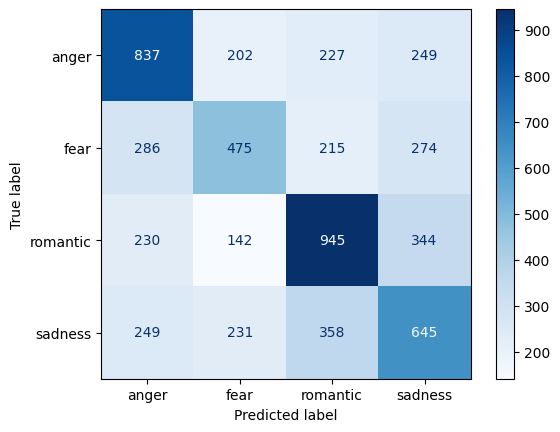

In [8]:
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
plt.figure(figsize=(12, 8))  # adjust width x height in inches

# Train model
model.fit(X_train, y_train)

# Predict
preds = model.predict(X_test)

# Classification report
print(classification_report(y_test, preds))

# Confusion matrix
cm = confusion_matrix(y_test, preds)
print("Confusion Matrix:\n", cm)
# Visualize confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues', values_format='d')
